# Phase 4 — Anomaly Detection & Business Recommendations

## 1. Introduction

**Phase 1** built **`fact_sales`** in PostgreSQL. **Phase 2** analyzed seasonality. **Phase 3** forecast daily revenue with ARIMA, Prophet, and LSTM.

**Phase 4** adds an operational layer:

- **Anomaly detection** — flag unusual daily revenue (spikes and drops)
- **Business recommendations** — rule-based actions tied to anomalies and drivers
- **Forecast comparison** — reconcile Phase 3 models against actuals
- **Pipeline & scenarios** — how the system updates daily; festival, weekend, and salary-cycle patterns

> **Prerequisite:** `fact_sales` in `sales_db`. Phase 3 optional (forecasts recomputed here if CSV exports are missing).


## 2. Library Imports & PostgreSQL Connection

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sqlalchemy import create_engine, text
from sqlalchemy.engine import Engine

from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

PG_USER = os.environ.get("PGUSER", "postgres")
PG_PASSWORD = os.environ.get("PGPASSWORD", "kanna")
PG_HOST = os.environ.get("PGHOST", "localhost")
PG_PORT = os.environ.get("PGPORT", "5432")
PG_DATABASE = os.environ.get("PGDATABASE", "sales_db")

CONNECTION_STRING = os.environ.get(
    "DATABASE_URL",
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}",
)
engine: Engine = create_engine(CONNECTION_STRING)
WORKSPACE = Path.cwd()
OUTPUT_DIR = WORKSPACE / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

def run_sql(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("PostgreSQL connection ready.")


PostgreSQL connection ready.


## 3. Load Time-Series Data

Daily revenue from `fact_sales`.


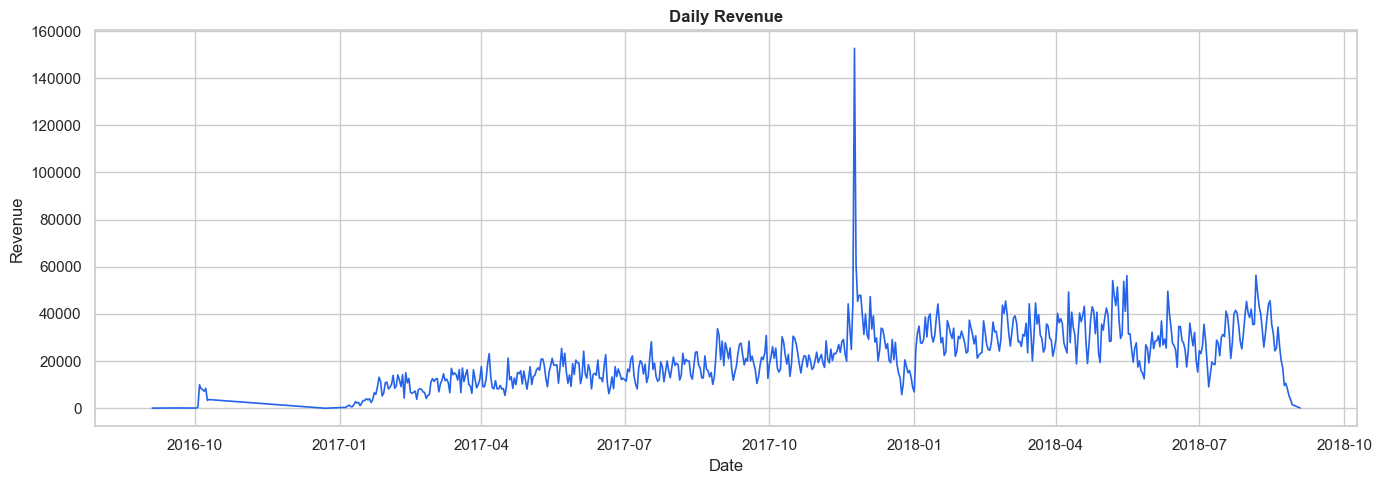

730 days | 2016-09-04 → 2018-09-03


In [2]:
DAILY_SQL = '''
SELECT order_date, SUM(total_revenue) AS daily_revenue
FROM fact_sales
GROUP BY order_date
ORDER BY order_date;
'''

raw = run_sql(DAILY_SQL)
raw["order_date"] = pd.to_datetime(raw["order_date"])
ts = raw.set_index("order_date").sort_index()
ts = ts.asfreq("D")
ts["daily_revenue"] = ts["daily_revenue"].interpolate(method="time").ffill().bfill()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts["daily_revenue"], color="#2563eb", lw=1.2)
ax.set_title("Daily Revenue", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

print(f"{len(ts)} days | {ts.index.min().date()} → {ts.index.max().date()}")


---

# Section 1 — Anomaly Detection

## 4. Z-Score Based Anomaly Detection

Flag days where \(|z| > \) threshold (default **2.5**). Positive z → **spike**; negative z → **drop**.


Z-score anomalies (|z| > 2.5): 6


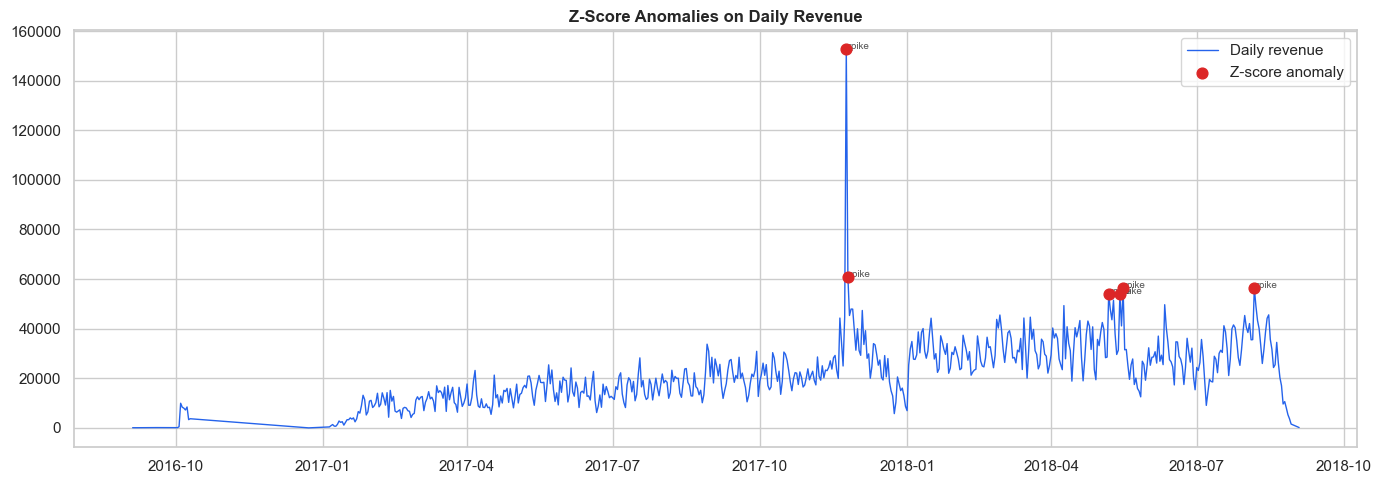

In [3]:
Z_THRESHOLD = 2.5
rev = ts["daily_revenue"].copy()
z_scores = stats.zscore(rev.values, nan_policy="omit")
ts["z_score"] = z_scores
ts["z_anomaly"] = np.abs(ts["z_score"]) > Z_THRESHOLD
ts["z_type"] = np.where(
    ts["z_anomaly"] & (ts["z_score"] > 0),
    "spike",
    np.where(ts["z_anomaly"] & (ts["z_score"] < 0), "drop", ""),
)

z_anoms = ts[ts["z_anomaly"]].copy()
print(f"Z-score anomalies (|z| > {Z_THRESHOLD}): {len(z_anoms)}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts["daily_revenue"], color="#2563eb", lw=1, label="Daily revenue")
ax.scatter(
    z_anoms.index,
    z_anoms["daily_revenue"],
    color="#dc2626",
    s=60,
    zorder=5,
    label="Z-score anomaly",
)
for idx, row in z_anoms.iterrows():
    ax.annotate(row["z_type"], (idx, row["daily_revenue"]), fontsize=7, alpha=0.8)
ax.set_title("Z-Score Anomalies on Daily Revenue", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Rolling Average Deviation

Anomaly when \(|revenue - rolling\_mean| > k \times rolling\_std\) (window **30**, **k = 2**).


Rolling anomalies: 51


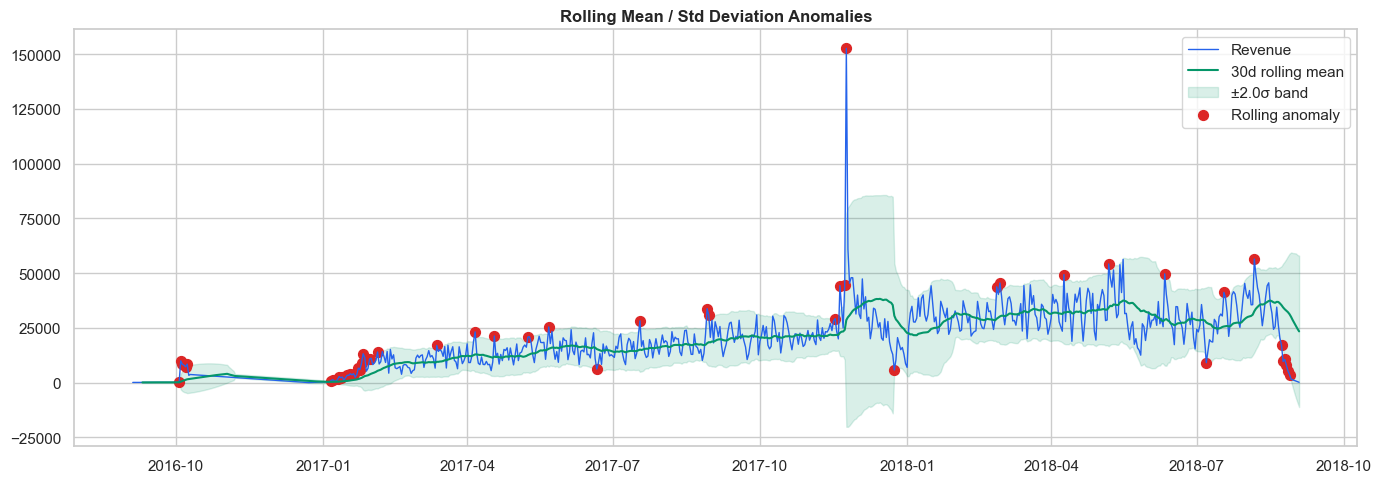

Both methods: 3 | Z-only: 3 | Rolling-only: 48


In [4]:
ROLL_WINDOW = 30
K_STD = 2.0

ts["roll_mean"] = rev.rolling(ROLL_WINDOW, min_periods=7).mean()
ts["roll_std"] = rev.rolling(ROLL_WINDOW, min_periods=7).std()
ts["roll_dev"] = (rev - ts["roll_mean"]).abs()
ts["roll_anomaly"] = ts["roll_dev"] > (K_STD * ts["roll_std"])
ts["roll_type"] = np.where(
    ts["roll_anomaly"] & (rev > ts["roll_mean"]),
    "spike",
    np.where(ts["roll_anomaly"] & (rev < ts["roll_mean"]), "drop", ""),
)

roll_anoms = ts[ts["roll_anomaly"]].copy()
print(f"Rolling anomalies: {len(roll_anoms)}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, rev, label="Revenue", color="#2563eb", lw=1)
ax.plot(ts.index, ts["roll_mean"], label=f"{ROLL_WINDOW}d rolling mean", color="#059669")
ax.fill_between(
    ts.index,
    ts["roll_mean"] - K_STD * ts["roll_std"],
    ts["roll_mean"] + K_STD * ts["roll_std"],
    alpha=0.15,
    color="#059669",
    label=f"±{K_STD}σ band",
)
ax.scatter(roll_anoms.index, roll_anoms["daily_revenue"], color="#dc2626", s=50, label="Rolling anomaly")
ax.set_title("Rolling Mean / Std Deviation Anomalies", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

both = ts[ts["z_anomaly"] & ts["roll_anomaly"]]
z_only = ts[ts["z_anomaly"] & ~ts["roll_anomaly"]]
roll_only = ts[~ts["z_anomaly"] & ts["roll_anomaly"]]
print(f"Both methods: {len(both)} | Z-only: {len(z_only)} | Rolling-only: {len(roll_only)}")


## 6. Anomaly Summary Table


In [5]:
def anomaly_rows(mask, method: str, type_col: str) -> pd.DataFrame:
    sub = ts.loc[mask, ["daily_revenue", type_col]].copy()
    sub = sub.rename(columns={"daily_revenue": "revenue", type_col: "anomaly_type"})
    sub["detection_method"] = method
    sub["date"] = sub.index
    return sub.reset_index(drop=True)[["date", "revenue", "anomaly_type", "detection_method"]]

summary_z = anomaly_rows(ts["z_anomaly"], "z-score", "z_type")
summary_roll = anomaly_rows(ts["roll_anomaly"], "rolling deviation", "roll_type")
anomaly_summary = (
    pd.concat([summary_z, summary_roll], ignore_index=True)
    .sort_values("date")
    .drop_duplicates(subset=["date", "detection_method"])
)

display(anomaly_summary.head(20))
print(f"Total anomaly rows: {len(anomaly_summary)}")
anomaly_summary.to_csv(OUTPUT_DIR / "phase4_anomaly_summary.csv", index=False)


,date,revenue,anomaly_type,detection_method
6,2016-10-03,463.48,spike,rolling deviation
7,2016-10-04,9940.96,spike,rolling deviation
8,2016-10-05,8343.25,spike,rolling deviation
9,2016-10-06,7960.51,spike,rolling deviation
10,2016-10-07,7228.05,spike,rolling deviation
11,2016-10-08,8441.85,spike,rolling deviation
12,2017-01-06,916.38,spike,rolling deviation
13,2017-01-07,1351.90,spike,rolling deviation
14,2017-01-10,1434.87,spike,rolling deviation
15,2017-01-11,2776.16,spike,rolling deviation


Total anomaly rows: 57


---

# Section 2 — Business Recommendation Layer

## 7. Convert Anomalies into Business Insights

For each flagged date we pull category and region breakdowns from `fact_sales` to contextualize spikes and drops.


In [6]:
def drivers_for_dates(dates: list) -> pd.DataFrame:
    if not dates:
        return pd.DataFrame()
    dmin, dmax = min(dates), max(dates)
    sql = f'''
    SELECT order_date::date AS d,
           product_category,
           customer_location AS region,
           SUM(total_revenue) AS revenue,
           AVG(delivery_time) AS avg_delivery_days
    FROM fact_sales
    WHERE order_date::date BETWEEN '{dmin}' AND '{dmax}'
    GROUP BY 1, 2, 3
    '''
    return run_sql(sql)

unique_dates = anomaly_summary["date"].dt.date.unique().tolist()
drivers = drivers_for_dates(unique_dates)

if len(drivers) > 0:
    top_cat = (
        drivers.groupby(["d", "product_category"])["revenue"].sum()
        .reset_index()
        .sort_values(["d", "revenue"], ascending=[True, False])
        .groupby("d")
        .head(1)
        .rename(columns={"product_category": "top_category"})
    )
    top_reg = (
        drivers.groupby(["d", "region"])["revenue"].sum()
        .reset_index()
        .sort_values(["d", "revenue"], ascending=[True, False])
        .groupby("d")
        .head(1)
        .rename(columns={"region": "top_region"})
    )
    anomaly_enriched = anomaly_summary.copy()
    anomaly_enriched["date_only"] = pd.to_datetime(anomaly_enriched["date"]).dt.date
    anomaly_enriched = anomaly_enriched.merge(
        top_cat.rename(columns={"d": "date_only"})[["date_only", "top_category"]],
        on="date_only",
        how="left",
    )
    anomaly_enriched = anomaly_enriched.merge(
        top_reg.rename(columns={"d": "date_only"})[["date_only", "top_region"]],
        on="date_only",
        how="left",
    )
    display(anomaly_enriched.head(15))
else:
    anomaly_enriched = anomaly_summary.copy()
    anomaly_enriched["top_category"] = None
    anomaly_enriched["top_region"] = None


,date,revenue,anomaly_type,detection_method,date_only,top_category,top_region
0,2016-10-03,463.48,spike,rolling deviation,2016-10-03,furniture_decor,mozarlandia
1,2016-10-04,9940.96,spike,rolling deviation,2016-10-04,consoles_games,rio de janeiro
2,2016-10-05,8343.25,spike,rolling deviation,2016-10-05,toys,vargem grande paulista
3,2016-10-06,7960.51,spike,rolling deviation,2016-10-06,perfumery,quissama
4,2016-10-07,7228.05,spike,rolling deviation,2016-10-07,perfumery,rio de janeiro
5,2016-10-08,8441.85,spike,rolling deviation,2016-10-08,watches_gifts,rio de janeiro
6,2017-01-06,916.38,spike,rolling deviation,2017-01-06,health_beauty,natal
7,2017-01-07,1351.90,spike,rolling deviation,2017-01-07,cool_stuff,mangueirinha
8,2017-01-10,1434.87,spike,rolling deviation,2017-01-10,watches_gifts,rio de janeiro
9,2017-01-11,2776.16,spike,rolling deviation,2017-01-11,garden_tools,sao joao do itaperiu


## 8. Recommendation Engine

Rule-based recommendations from anomaly type, category, region, and delivery delays.


In [7]:
def build_recommendation(row) -> str:
    atype = row.get("anomaly_type", "")
    cat = row.get("top_category")
    reg = row.get("top_region")
    method = row.get("detection_method", "")

    if atype == "spike":
        rec = "Demand surge detected: increase safety stock and staffing for fulfillment."
        if pd.notna(cat):
            rec += f" Prioritize category '{cat}'."
        if pd.notna(reg):
            rec += f" Focus on region '{reg}'."
    elif atype == "drop":
        rec = "Revenue drop detected: review marketing, payments, and supply constraints."
        if pd.notna(cat):
            rec += f" Investigate category '{cat}' (pricing, stockouts, competition)."
        if pd.notna(reg):
            rec += f" Run operational review in region '{reg}'."
    else:
        rec = "Monitor; anomaly signal unclear."

    if method == "rolling deviation":
        rec += " (Confirmed vs recent baseline — not just long-run outlier.)"
    return rec

if "anomaly_enriched" in dir():
    rec_df = anomaly_enriched.copy()
else:
    rec_df = anomaly_summary.copy()
    rec_df["top_category"] = None
    rec_df["top_region"] = None

rec_df["recommendation"] = rec_df.apply(build_recommendation, axis=1)

# Delivery correlation on drop days
drop_dates = rec_df.loc[rec_df["anomaly_type"] == "drop", "date"].dt.date.unique().tolist()
if drop_dates and len(drivers) > 0:
    avg_del = drivers.groupby("d")["avg_delivery_days"].mean()
    slow = avg_del[avg_del > avg_del.median() + 2].index.tolist()
    if slow:
        rec_df.loc[
            rec_df["date"].dt.date.isin(slow),
            "recommendation",
        ] += " Elevated delivery times — recommend logistics / carrier review."

recommendations = (
    rec_df[["date", "revenue", "anomaly_type", "detection_method", "top_category", "top_region", "recommendation"]]
    .drop_duplicates()
    .sort_values("date")
)

display(recommendations)
recommendations.to_csv(OUTPUT_DIR / "phase4_recommendations.csv", index=False)
print(f"Saved {len(recommendations)} recommendations to outputs/")


,date,revenue,anomaly_type,detection_method,top_category,top_region,recommendation
0,2016-10-03,463.48,spike,rolling deviation,furniture_decor,mozarlandia,Demand surge detected: increase safety stock a...
1,2016-10-04,9940.96,spike,rolling deviation,consoles_games,rio de janeiro,Demand surge detected: increase safety stock a...
2,2016-10-05,8343.25,spike,rolling deviation,toys,vargem grande paulista,Demand surge detected: increase safety stock a...
3,2016-10-06,7960.51,spike,rolling deviation,perfumery,quissama,Demand surge detected: increase safety stock a...
4,2016-10-07,7228.05,spike,rolling deviation,perfumery,rio de janeiro,Demand surge detected: increase safety stock a...
5,2016-10-08,8441.85,spike,rolling deviation,watches_gifts,rio de janeiro,Demand surge detected: increase safety stock a...
6,2017-01-06,916.38,spike,rolling deviation,health_beauty,natal,Demand surge detected: increase safety stock a...
7,2017-01-07,1351.90,spike,rolling deviation,cool_stuff,mangueirinha,Demand surge detected: increase safety stock a...
8,2017-01-10,1434.87,spike,rolling deviation,watches_gifts,rio de janeiro,Demand surge detected: increase safety stock a...
9,2017-01-11,2776.16,spike,rolling deviation,garden_tools,sao joao do itaperiu,Demand surge detected: increase safety stock a...


Saved 57 recommendations to outputs/


---

# Section 3 — Forecast Model Comparison

## 9. Load Forecast Results from Phase 3

Loads `outputs/phase3_test_predictions.csv` if Phase 3 exported it; otherwise recomputes ARIMA / Prophet / LSTM on the same 90-day test split.


In [8]:
def mae(y, p):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))

def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

def mape(y, p, eps=1e-8):
    y, p = np.asarray(y), np.asarray(p)
    m = np.abs(y) > eps
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100) if m.any() else float("nan")

PHASE3_CSV = OUTPUT_DIR / "phase3_test_predictions.csv"
TEST_DAYS = 90

y = ts["daily_revenue"]
train, test = y.iloc[:-TEST_DAYS], y.iloc[-TEST_DAYS:]

if PHASE3_CSV.exists():
    pred_df = pd.read_csv(PHASE3_CSV, parse_dates=["date"])
    pred_df = pred_df.set_index("date").reindex(test.index)
    print("Loaded Phase 3 exports:", PHASE3_CSV)
else:
    print("Phase 3 CSV not found — recomputing forecasts (same 90-day test split).")
    pred_df = pd.DataFrame({"actual": test.values}, index=test.index)

    try:
        import pmdarima as pm
        from statsmodels.tsa.arima.model import ARIMA
        order = pm.auto_arima(train.values, seasonal=False, suppress_warnings=True, error_action="ignore").order
    except Exception:
        from statsmodels.tsa.arima.model import ARIMA
        order = (1, 1, 1)
    pred_df["arima"] = ARIMA(train, order=order).fit().forecast(len(test)).values

    try:
        from prophet import Prophet
        pf = pd.DataFrame({"ds": train.index, "y": train.values})
        m = Prophet(weekly_seasonality=True, yearly_seasonality=len(train) > 365)
        m.fit(pf)
        fc = m.predict(m.make_future_dataframe(len(test), freq="D"))
        pred_df["prophet"] = fc.set_index("ds").loc[test.index, "yhat"].values
    except Exception as e:
        print("Prophet skip:", e)

    try:
        import tensorflow as tf
        from tensorflow.keras import layers
        from tensorflow import keras
        tf.random.set_seed(RANDOM_SEED)
        lookback = 30
        scaler = MinMaxScaler()
        tr = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
        te = scaler.transform(test.values.reshape(-1, 1)).flatten()
        comb = np.concatenate([tr, te])
        X, y_s = [], []
        for i in range(lookback, len(comb)):
            X.append(comb[i - lookback : i])
            y_s.append(comb[i])
        X = np.array(X).reshape(-1, lookback, 1)
        model = keras.Sequential([layers.LSTM(32, input_shape=(lookback, 1)), layers.Dense(1)])
        model.compile(optimizer="adam", loss="mse")
        Xtr, ytr = X[: len(tr) - lookback], y_s[: len(tr) - lookback]
        model.fit(Xtr, ytr, epochs=20, batch_size=32, verbose=0, shuffle=False)
        pred_df["lstm"] = scaler.inverse_transform(model.predict(X[len(tr) - lookback :], verbose=0)).flatten()
    except Exception as e:
        print("LSTM skip:", e)

    pred_df.to_csv(PHASE3_CSV)
    print("Wrote", PHASE3_CSV)

display(pred_df.head())


Phase 3 CSV not found — recomputing forecasts (same 90-day test split).


23:01:41 - cmdstanpy - INFO - Chain [1] start processing
23:01:41 - cmdstanpy - INFO - Chain [1] done processing


LSTM skip: tuple index out of range
Wrote d:\NCPL\Bootcamp\Projects\Project 3\data\outputs\phase3_test_predictions.csv


,actual,arima,prophet
order_date,,,
2018-06-06,26134.40,27971.719259,30173.796602
2018-06-07,37020.40,26982.782407,29383.343991
2018-06-08,26870.41,26982.782407,29588.384338
2018-06-09,29325.08,26982.782407,25359.579271
2018-06-10,25501.97,26982.782407,26088.004096


## 10. Compare Models

MAE, RMSE, MAPE on the test period; overlay plots and interpretation.


,MAE,RMSE,MAPE (%)
model,,,
ARIMA,9546.71,12294.58,427.31
PROPHET,9101.67,12668.81,538.89


Best model (lowest RMSE): ARIMA


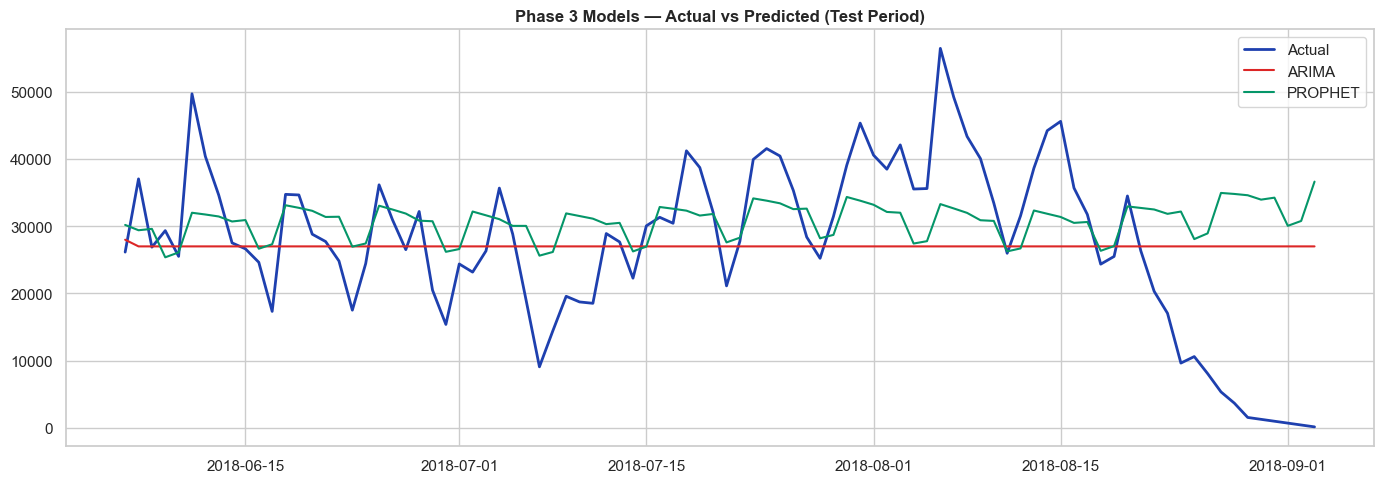

In [9]:
actual = pred_df["actual"] if "actual" in pred_df.columns else test
metric_rows = []
plot_cols = []

for col in ["arima", "prophet", "lstm"]:
    if col in pred_df.columns and pred_df[col].notna().any():
        vals = pred_df[col].dropna()
        aligned_actual = actual.loc[vals.index]
        metric_rows.append({
            "model": col.upper(),
            "MAE": round(mae(aligned_actual, vals), 2),
            "RMSE": round(rmse(aligned_actual, vals), 2),
            "MAPE (%)": round(mape(aligned_actual, vals), 2),
        })
        plot_cols.append(col)

forecast_compare = pd.DataFrame(metric_rows).set_index("model")
display(forecast_compare)

if len(plot_cols):
    best = forecast_compare["RMSE"].idxmin()
    print("Best model (lowest RMSE):", best)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test.values, label="Actual", color="#1e40af", lw=2)
colors = {"arima": "#dc2626", "prophet": "#059669", "lstm": "#7c3aed"}
for c in plot_cols:
    ax.plot(pred_df.index, pred_df[c], label=c.upper(), color=colors.get(c, "gray"), lw=1.5)
ax.set_title("Phase 3 Models — Actual vs Predicted (Test Period)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

forecast_compare.to_csv(OUTPUT_DIR / "phase4_forecast_comparison.csv")


**Interpretation (edit after your run):**

- **Best model:** Lowest RMSE on the holdout — often **Prophet** when weekly/yearly seasonality is strong; **ARIMA** when the series is smooth; **LSTM** when patterns are nonlinear *and* enough data/tuning exist.
- **ARIMA:** Fast, interpretable; struggles with structural breaks and multiple seasonalities.
- **Prophet:** Strong seasonality + holidays; can overfit short histories; wide intervals reflect uncertainty.
- **LSTM:** Flexible but needs volume and tuning; the simple baseline here is for comparison only.


---

# Section 4 — Data Pipeline Thinking

## 11. Daily Auto-Update Pipeline Concept

End-to-end flow when new Olist (or operational) files arrive each day:

1. **Ingest** — land raw CSV/API files in object storage or staging schema.
2. **Incremental load** — append only new/changed orders to `staging_*` tables (merge on `order_id` + `order_item_id`).
3. **Refresh `fact_sales`** — upsert fact rows for new items; recompute derived fields (`delivery_time`, revenue).
4. **Anomaly job** — recompute daily revenue series; run z-score + rolling rules; write `phase4_anomaly_summary.csv`.
5. **Forecast job** — nightly or weekly retrain / rolling refit; update 90-day forecast table.
6. **Recommendations** — apply rule engine to new anomalies; push to Slack/email or BI dataset.
7. **Dashboards** — Power BI / Metabase / Grafana reading PostgreSQL marts + latest anomaly/forecast tables.

**Design principles:** idempotent jobs, partitioned by `order_date`, monitor job duration and row counts, alert when anomaly count spikes.


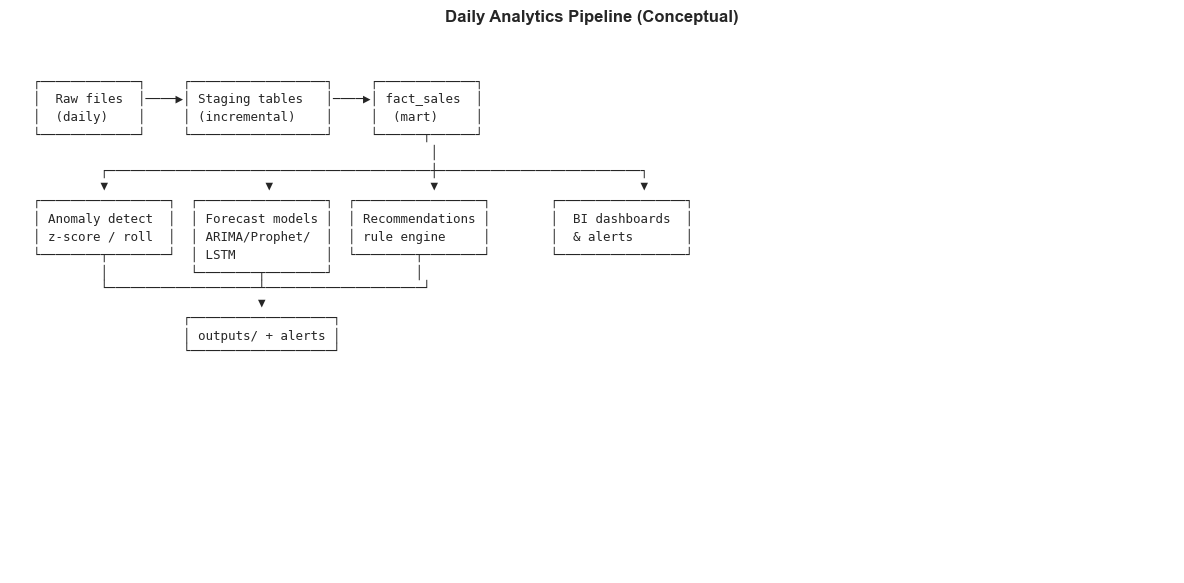

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")
diagram = '''
┌─────────────┐     ┌──────────────────┐     ┌─────────────┐
│  Raw files  │────▶│ Staging tables   │────▶│ fact_sales  │
│  (daily)    │     │ (incremental)    │     │  (mart)     │
└─────────────┘     └──────────────────┘     └──────┬──────┘
                                                     │
         ┌───────────────────────────────────────────┼───────────────────────────┐
         ▼                     ▼                     ▼                           ▼
┌─────────────────┐  ┌─────────────────┐  ┌─────────────────┐        ┌─────────────────┐
│ Anomaly detect  │  │ Forecast models │  │ Recommendations │        │  BI dashboards  │
│ z-score / roll  │  │ ARIMA/Prophet/  │  │ rule engine     │        │  & alerts       │
└────────┬────────┘  │ LSTM            │  └────────┬────────┘        └─────────────────┘
         │           └────────┬────────┘           │
         └────────────────────┴─────────────────────┘
                              ▼
                    ┌───────────────────┐
                    │ outputs/ + alerts │
                    └───────────────────┘
'''
ax.text(0.02, 0.98, diagram, va="top", family="monospace", fontsize=9)
ax.set_title("Daily Analytics Pipeline (Conceptual)", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


---

# Section 5 — Scenario-Based Insights

## 12. Scenario Analysis

Patterns: weekends vs weekdays, month-end (salary) effects, seasonal months, and top spike days (proxy for festivals/promotions).


,mean,sum,count
is_weekend,,,
Weekday,23859.878295,10498346.45,440
Weekend,17575.552557,3093297.25,176


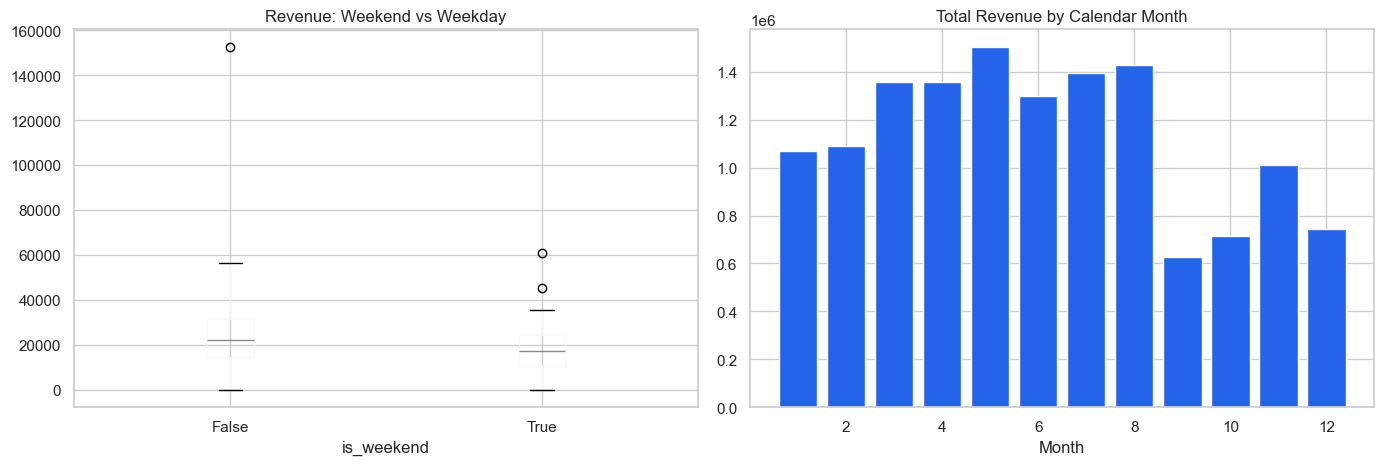

Avg daily revenue — month-end effect:


is_month_end
Day 1–24     22300.086388
Day 25–31    21147.629921
Name: revenue, dtype: float64

Top revenue spike days (z-score):


,daily_revenue,z_score
order_date,,
2017-11-24,152653.74,9.687651
2017-11-25,60923.48,3.047908
2018-08-06,56427.39,2.722466
2018-05-16,56283.73,2.712067
2018-05-07,54167.48,2.558886
2018-05-14,53842.38,2.535354
2018-05-10,51458.67,2.362813
2018-06-11,49669.70,2.233321


In [11]:
scenario_sql = '''
SELECT
  order_date::date AS d,
  EXTRACT(DOW FROM order_date) AS dow,
  EXTRACT(DAY FROM order_date) AS dom,
  EXTRACT(MONTH FROM order_date) AS month,
  SUM(total_revenue) AS revenue,
  COUNT(*) AS line_items,
  AVG(delivery_time) AS avg_delivery
FROM fact_sales
GROUP BY 1, 2, 3, 4
ORDER BY 1;
'''
sc = run_sql(scenario_sql)
sc["d"] = pd.to_datetime(sc["d"])
sc["weekday"] = sc["d"].dt.day_name()
sc["is_weekend"] = sc["dow"].isin([0, 6])
sc["is_month_end"] = sc["dom"] >= 25

# Weekend vs weekday
wk = sc.groupby("is_weekend")["revenue"].agg(["mean", "sum", "count"]).rename(index={False: "Weekday", True: "Weekend"})
display(wk)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.boxplot(column="revenue", by="is_weekend", ax=axes[0])
axes[0].set_title("Revenue: Weekend vs Weekday")
monthly = sc.groupby("month")["revenue"].sum()
axes[1].bar(monthly.index, monthly.values, color="#2563eb")
axes[1].set_title("Total Revenue by Calendar Month")
axes[1].set_xlabel("Month")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Month-end vs rest
me = sc.groupby("is_month_end")["revenue"].mean().rename(index={False: "Day 1–24", True: "Day 25–31"})
print("Avg daily revenue — month-end effect:")
display(me)

# Top spike days (z-score)
top_spikes = ts.nlargest(8, "z_score")[["daily_revenue", "z_score"]]
print("Top revenue spike days (z-score):")
display(top_spikes)
